In [26]:
!pip install numpy 
!pip install pandas 
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn






[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [28]:

df=pd.read_csv(r"C:\Users\LOQ\Downloads\spam.csv\spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [29]:
df.shape


(5572, 2)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [31]:
df[df.isnull().any(axis=1)]


,Category,Message


In [32]:
df.isnull().sum().sum()
df.columns

Index(['Category', 'Message'], dtype='str')

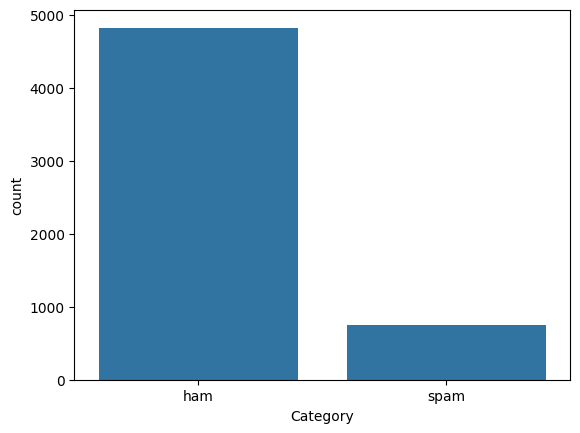

In [33]:
#visualization
sns.countplot(data=df,x='Category' )
plt.show()

In [34]:
df['length']=df['Message'].apply(len)

In [35]:
df['length'],df['Message'][0]

(0       111
 1        29
 2       155
 3        49
 4        61
        ... 
 5567    160
 5568     36
 5569     57
 5570    125
 5571     26
 Name: length, Length: 5572, dtype: int64,
 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

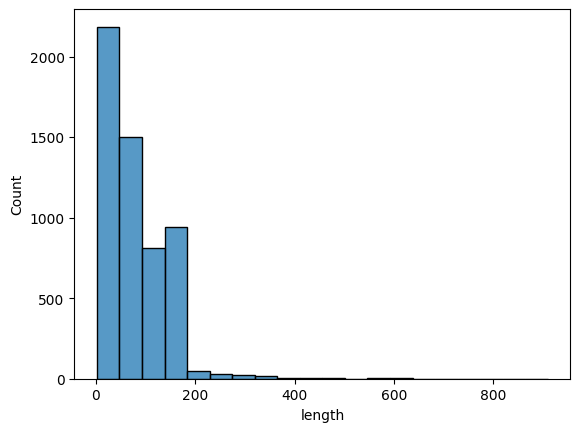

In [36]:
sns.histplot(data=df,x='length',bins=20)
plt.show()

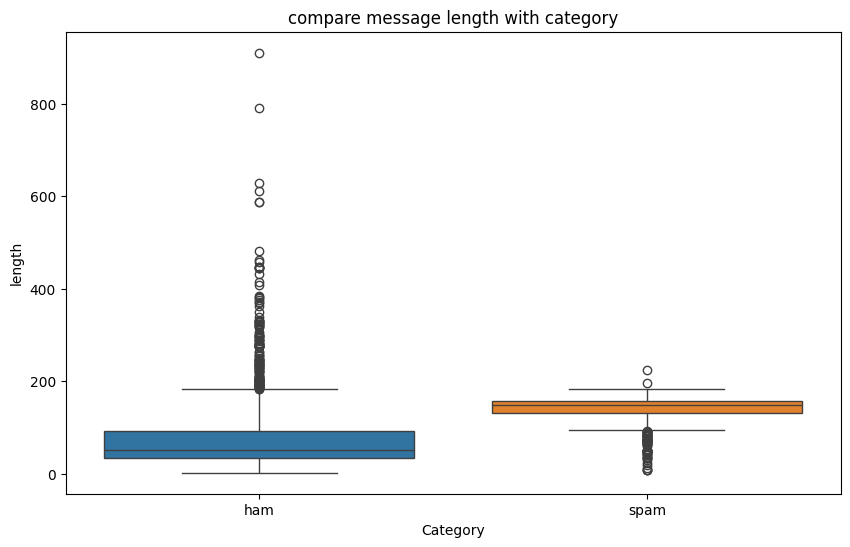

In [37]:
#compare message length with category
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category',y='length',hue='Category')
plt.title('compare message length with category')
plt.show()

In [38]:
#label encoding
from sklearn.preprocessing import LabelEncoder
encode=LabelEncoder()
df['encoder']=encode.fit_transform(df['Category'])

In [39]:
df['encoder']

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: encoder, Length: 5572, dtype: int64

In [40]:
spam_per=df['encoder'].value_counts(normalize=True)*100
spam_per

encoder
0    86.593683
1    13.406317
Name: proportion, dtype: float64

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
vect=TfidfVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{2,}\b")
x=vect.fit_transform(df['Message'])

In [42]:
vect.get_feature_names_out()[:10]


array(['aa', 'aah', 'aaniye', 'aaooooright', 'aathi', 'ab', 'abbey',
       'abdomen', 'abeg', 'abel'], dtype=object)

In [43]:
x.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 7586))

In [44]:
x.shape

(5572, 7586)

In [45]:
#train
from sklearn.model_selection import train_test_split
y=df['encoder']
x_train,x_test,y_train,y_test=train_test_split(x,y,
test_size=0.2,
random_state=42)

In [46]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3859., 598.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7586)","[[0. ,1.27,0.08,...,0.29,0. ,0.16], [0. ,0. ,0. ,...,0. ,0.32,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7586)","[[-9.88,-9.06,-9.81,...,-9.62,-9.88,-9.73], [-9.21,-9.21,-9.21,...,-9.21,-8.93,-9.21]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7586


In [47]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=model.predict(x_test)
print("accuracy:",accuracy_score(y_pred,y_test))
print("classification :",classification_report(y_pred,y_test))
      

accuracy: 0.9641255605381166
classification :               precision    recall  f1-score   support

           0       1.00      0.96      0.98      1006
           1       0.73      1.00      0.84       109

    accuracy                           0.96      1115
   macro avg       0.87      0.98      0.91      1115
weighted avg       0.97      0.96      0.97      1115



In [53]:
def predict_sms(text):
    
    text_vector = vect.transform([text])

    pred = model.predict(text_vector)
   
    if pred[0] == 1:
        return "Spam"
    else:
        return "Ham"

In [54]:
predict_sms("Free entry in lottery")

'Spam'